<a href="https://colab.research.google.com/github/lavenderoyugi/-Bicycle-Parking-Infrastructure-Analysis-in-the-Loire-Atlantique-Area-/blob/main/Bicycle_Parking_Infrastructure_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Bicycle Parking Infrastructure Analysis — Loire-Atlantique

## Project Overview

This project analyses recorded bicycle-parking infrastructure in the Loire-Atlantique area using open data.

The analysis focuses on:

- the geographic distribution of bicycle-parking facilities
- parking capacity
- capacity distribution across municipalities
- infrastructure types
- data completeness

The objective is to transform the raw dataset into clear, evidence-based insights about the distribution and characteristics of bicycle-parking infrastructure.

### Key Questions

1. Where are bicycle-parking facilities concentrated?
2. How large are the individual facilities?
3. Which municipalities account for the largest share of capacity?
4. Which infrastructure types are most common?
5. Which fields are complete enough to support further analysis?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

#### 1. Data Loading

The dataset contains recorded bicycle-parking locations and associated infrastructure characteristics.

In [9]:
link = ("/content/244400644_stationnements_cyclables.csv")
df = pd.read_csv(link,sep=';')
df.head()

,geo_point_2d,Geo Shape,id_local,id_osm,code_com,coordonneesxy,capacite,capacite_cargo,type_accroche,mobilier,...,couverture,surveillance,lumiere,url_info,d_service,source,proprietaire,gestionnaire,date_maj,commentaires
0,"47.24014209999996, -2.2782823","{""coordinates"": [-2.2782823, 47.24014209999996...",40,n1655161104,44184,"[-2.2782823000000034,47.24014210000001]",4,NaN,ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© les contributeurs d’OpenStreetMap ; © CARENE,NaN,NaN,2022-09-19,NaN
1,"47.275722860270285, -2.205563401614654","{""coordinates"": [-2.205563401614654, 47.275722...",82,n1655161426,44184,"[-2.2055634016146564,47.27572286027034]",6,NaN,CADRE ET ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© les contributeurs d’OpenStreetMap ; © CARENE,NaN,NaN,2022-09-19,NaN
2,"47.285041587733524, -2.225726700976113","{""coordinates"": [-2.225726700976113, 47.285041...",540,NaN,44184,"[-2.225726700976119,47.28504158773357]",2,NaN,CADRE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,NaN
3,"47.297832194912985, -2.193971151595806","{""coordinates"": [-2.193971151595806, 47.297832...",544,NaN,44184,"[-2.193971151595806,47.29783219491302]",3,NaN,ROUE,ARCEAU,...,Faux,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,"stationnement amovible, mis à dispo par la lav..."
4,"47.28585974973144, -2.195954751533444","{""coordinates"": [-2.195954751533444, 47.285859...",545,NaN,44184,"[-2.195954751533448,47.28585974973149]",30,NaN,ROUE,RATELIER,...,Vrai,Faux,Faux,NaN,NaN,© CARENE,NaN,NaN,2022-09-19,salariés des chantiers navals


In [10]:
# Create latitude and longitude from the geographic coordinate field

df[["latitude", "longitude"]] = (
    df["geo_point_2d"]
    .str.split(",", expand=True)
    .astype(float)
)

df[["latitude", "longitude"]].head()

,latitude,longitude
0,47.240142,-2.278282
1,47.275723,-2.205563
2,47.285042,-2.225727
3,47.297832,-2.193971
4,47.285860,-2.195955


In [11]:
df.shape

(601, 25)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   geo_point_2d    601 non-null    object 
 1   Geo Shape       601 non-null    object 
 2   id_local        601 non-null    int64  
 3   id_osm          439 non-null    object 
 4   code_com        601 non-null    int64  
 5   coordonneesxy   601 non-null    object 
 6   capacite        601 non-null    int64  
 7   capacite_cargo  1 non-null      float64
 8   type_accroche   601 non-null    object 
 9   mobilier        601 non-null    object 
 10  acces           601 non-null    object 
 11  gratuit         601 non-null    object 
 12  protection      601 non-null    object 
 13  couverture      589 non-null    object 
 14  surveillance    290 non-null    object 
 15  lumiere         290 non-null    object 
 16  url_info        10 non-null     object 
 17  d_service       11 non-null     flo

## 2. Data Quality Check

Before analysing the infrastructure, we check the structure of the dataset, missing values and key analytical fields.

In [13]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 601
Columns: 25


In [14]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
capacite_cargo,600
url_info,591
d_service,590
proprietaire,579
commentaires,570
gestionnaire,483
surveillance,311
lumiere,311
id_osm,162
couverture,12


In [15]:
key_columns = [
    "capacite",
    "latitude",
    "longitude",
    "code_com",
    "type_accroche"
]

df[key_columns].isna().sum()

,0
capacite,0
latitude,0
longitude,0
code_com,0
type_accroche,0


##Project KPI summary

## 3. Dataset Overview

The dataset contains 601 recorded bicycle-parking locations across 10 municipalities.

In [16]:
total_locations = len(df)
total_capacity = df["capacite"].sum()
average_capacity = df["capacite"].mean()
median_capacity = df["capacite"].median()
municipalities = df["code_com"].nunique()

print(f"Parking locations: {total_locations:,}")
print(f"Total bicycle spaces: {total_capacity:,}")
print(f"Average capacity: {average_capacity:.1f}")
print(f"Median capacity: {median_capacity:.0f}")
print(f"Municipalities: {municipalities}")

Parking locations: 601
Total bicycle spaces: 4,585
Average capacity: 7.6
Median capacity: 6
Municipalities: 10


##Geographic distribution — Visual 1

## 4. Geographic Distribution

### Question

Where are bicycle-parking facilities concentrated?

Using the latitude and longitude fields, we map the recorded parking locations to understand their spatial distribution.

In [17]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

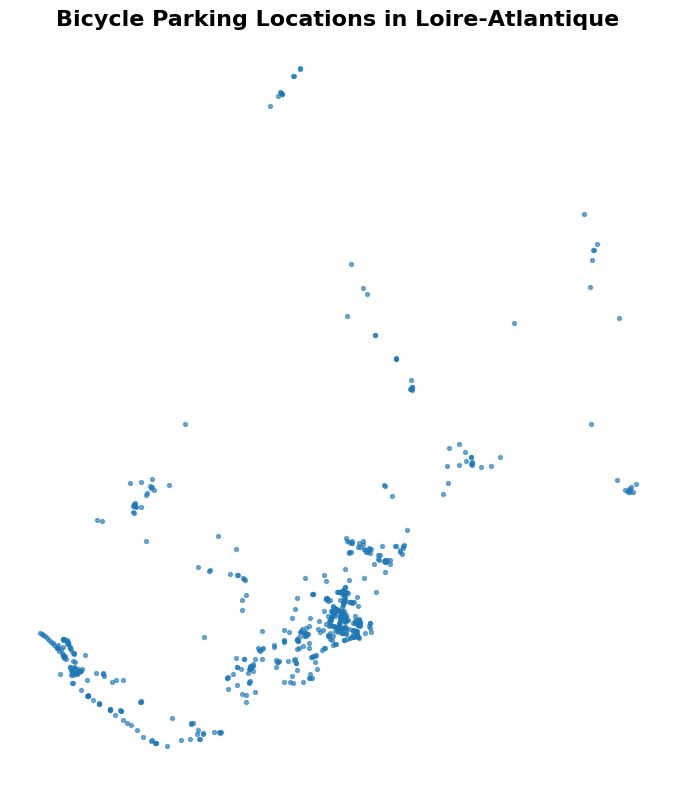

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    ax=ax,
    markersize=8,
    alpha=0.6
)

ax.set_title(
    "Bicycle Parking Locations in Loire-Atlantique",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

### Insight

The recorded infrastructure is geographically concentrated, with Saint-Nazaire accounting for the largest share of recorded parking locations.

##Capacity distribution — Visual 2

## 5. Parking Capacity

### Question

How large are individual bicycle-parking facilities?

We examine the distribution of parking capacity across the 601 recorded locations.

In [19]:
print(df["capacite"].describe())

count    601.000000
mean       7.628952
std        5.392627
min        0.000000
25%        4.000000
50%        6.000000
75%       10.000000
max       48.000000
Name: capacite, dtype: float64


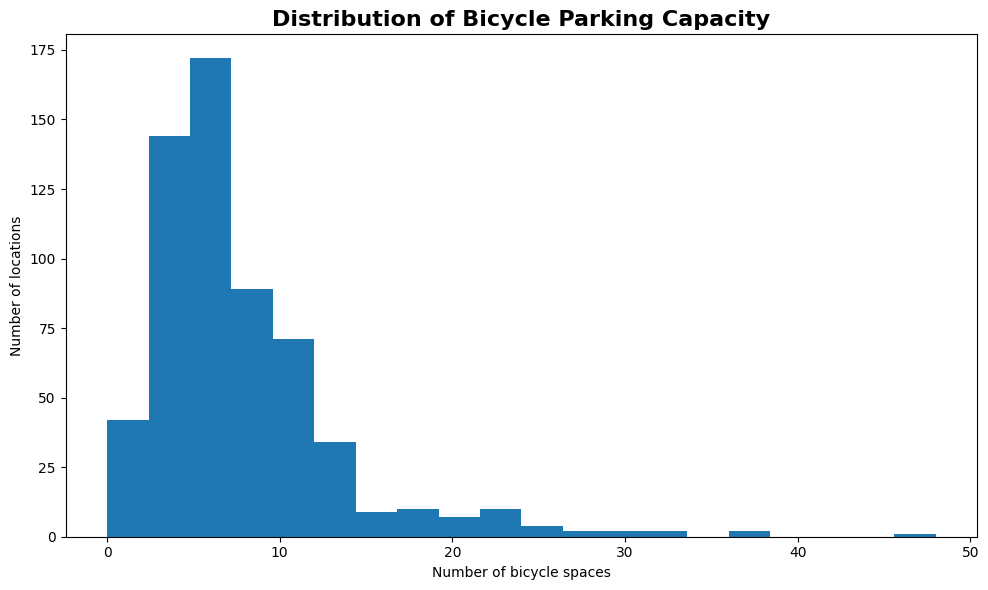

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["capacite"],
    bins=20
)

ax.set_title(
    "Distribution of Bicycle Parking Capacity",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of bicycle spaces")
ax.set_ylabel("Number of locations")

plt.tight_layout()
plt.show()

### Insight

Most facilities have relatively small capacity. The median facility provides 6 spaces, while the distribution is right-skewed by a small number of larger facilities.

###Capacity by municipality — Visual 3

##  Capacity by Municipality

### Question

How is bicycle-parking capacity distributed geographically across municipalities?

In [30]:
municipality_names = {
    44184: "Saint-Nazaire",
    44132: "Pornichet",
    44210: "Trignac",
    44151: "Saint-André-des-Eaux",
    44103: "Montoir-de-Bretagne",
    44052: "Donges",
    44030: "La Chapelle-des-Marais",
    44176: "Saint-Malo-de-Guersac",
    44013: "Besné",
    44168: "Saint-Joachim"
}

In [31]:
capacity_by_municipality = (
    df.groupby("code_com")["capacite"]
    .sum()
    .sort_values(ascending=False)
)

capacity_by_municipality.index = (
    capacity_by_municipality.index.map(municipality_names)
)

capacity_by_municipality

,capacite
code_com,
Saint-Nazaire,3001
Pornichet,949
Trignac,171
Saint-André-des-Eaux,116
Montoir-de-Bretagne,114
Donges,65
La Chapelle-des-Marais,57
Saint-Malo-de-Guersac,48
Besné,33


In [32]:
df["code_com"].unique()

array([44184, 44103, 44132, 44210, 44168, 44013, 44052, 44151, 44030,
       44176])

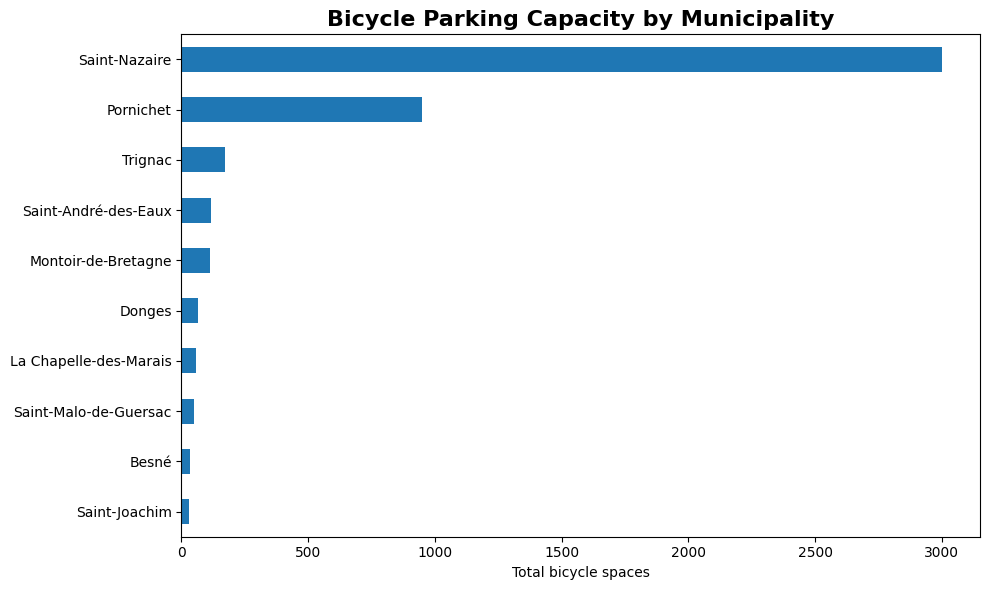

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

capacity_by_municipality.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "Bicycle Parking Capacity by Municipality",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Total bicycle spaces")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Insight

Parking capacity is highly concentrated geographically. Saint-Nazaire accounts for 3,001 recorded bicycle spaces, substantially more than the other municipalities represented in the dataset.

###Infrastructure types — Visual 4

## 7. Infrastructure Types

### Question

Which bicycle-parking infrastructure types are most common?

In [25]:
rack_counts = (
    df["type_accroche"]
    .value_counts()
)

rack_counts

,count
type_accroche,
CADRE ET ROUE,479
ROUE,67
CADRE,55


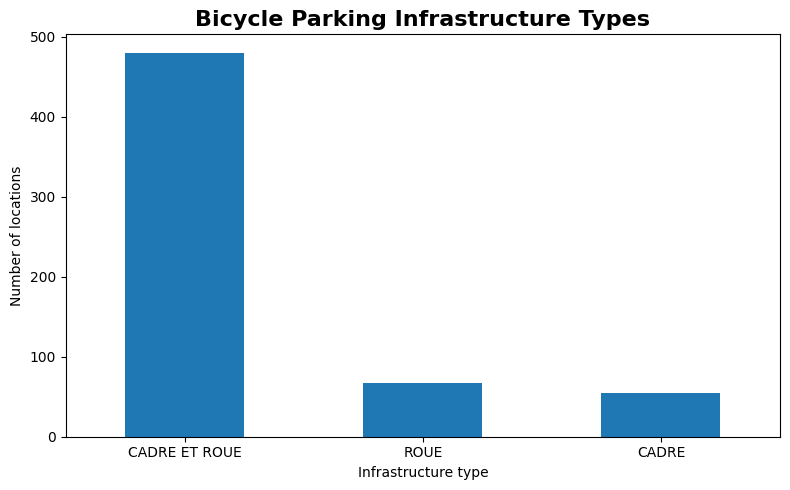

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

rack_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Bicycle Parking Infrastructure Types",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Infrastructure type")
ax.set_ylabel("Number of locations")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

### Insight

CADRE ET ROUE is the predominant infrastructure type, representing
479 of the 601 recorded locations.

##Data completeness — Visual 5

## 8. Data Completeness

### Question

Which fields are sufficiently complete for analysis, and where are important gaps?

In [27]:
completeness = (
    df.notna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

completeness

,0
geo_point_2d,100.000000
Geo Shape,100.000000
id_local,100.000000
code_com,100.000000
coordonneesxy,100.000000
type_accroche,100.000000
capacite,100.000000
acces,100.000000
mobilier,100.000000
date_maj,100.000000


In [28]:
important_fields = [
    "capacite",
    "latitude",
    "longitude",
    "code_com",
    "type_accroche",
    "proprietaire",
    "gestionnaire",
    "capacite_cargo"
]

completeness[important_fields]

,0
capacite,100.000000
latitude,100.000000
longitude,100.000000
code_com,100.000000
type_accroche,100.000000
proprietaire,3.660566
gestionnaire,19.633943
capacite_cargo,0.166389


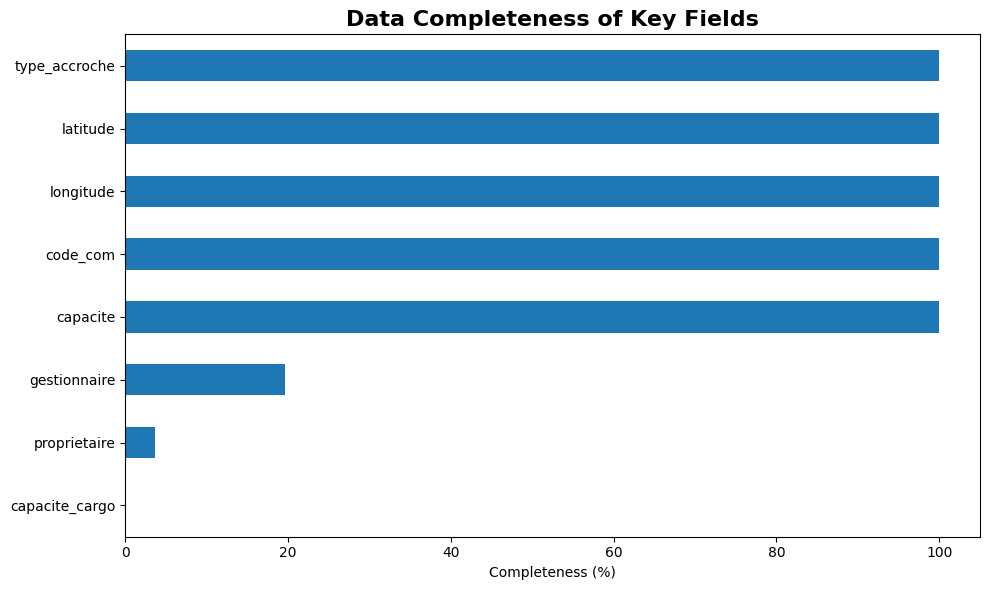

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

completeness[important_fields].sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "Data Completeness of Key Fields",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Completeness (%)")

plt.tight_layout()
plt.show()

### Insight

Core analytical fields such as capacity and geographic coordinates are complete, while several operational fields contain substantial missing values. This limits some forms of deeper infrastructure analysis.

Final conclusions

# 9. Key Findings

### 1. Geographic concentration
The recorded bicycle-parking infrastructure is concentrated in a limited number of municipalities, with Saint-Nazaire representing the largest concentration.

### 2. Small facilities dominate
The median facility provides 6 spaces, while only a small number of locations have substantially higher capacity.

### 3. Capacity is geographically concentrated
Saint-Nazaire accounts for 3,001 recorded bicycle spaces, making it the largest concentration of capacity in the dataset.

### 4. Infrastructure type

CADRE ET ROUE is the most common infrastructure type, representing
479 of the 601 recorded locations.

### 5. Data completeness varies
Core location and capacity fields are highly complete, while several operational attributes contain missing information.

## Conclusion

This analysis demonstrates how open geospatial data can be transformed into practical insights about the distribution, capacity and characteristics of bicycle-parking infrastructure.

The analysis combines Python, Pandas, GeoPandas, Matplotlib and Folium to support data preparation, spatial analysis and visual communication.